# HMM & AR-HMM Regime Detection

**Imports & Configuration**

In [263]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.dates as mdates
import statsmodels.api as sm
import warnings
warnings.filterwarnings("ignore")

DATA_PATH  = "../../data/processed/US/us_macro_2007_2023.csv"
K_REGIMES  = 2        # 2-state model
AR_ORDER   = 1        # AR lag order for AR-HMM

print(f"K_REGIMES = {K_REGIMES}  |  AR_ORDER = {AR_ORDER}")
print(f"Data path : {DATA_PATH}")


K_REGIMES = 2  |  AR_ORDER = 1
Data path : ../../data/processed/US/us_macro_2007_2023.csv


**Data Loading**

In [264]:
df = pd.read_csv(DATA_PATH, index_col=0, parse_dates=True)
df.index.name = "Date"

print("Dataset loaded successfully")
print(f"  Shape   : {df.shape}")
print(f"  Period  : {df.index[0].date()}  \u2192  {df.index[-1].date()}")
print(f"  Columns : {list(df.columns)}")
print()


Dataset loaded successfully
  Shape   : (187, 9)
  Period  : 2008-01-01  →  2023-07-01
  Columns : ['CPIAUCSL', 'UNRATE', 'FEDFUNDS', 'INDPRO', 'Inflation_MoM', 'Inflation_YoY', 'IP_MoM', 'News_Sentiment', 'Article_Count']



In [265]:
# ── Target variable: Month-over-Month inflation
y_inflation = df["Inflation_MoM"].dropna()

# Drop rows where target is missing; align all series to that index
df_model = df.loc[y_inflation.index].copy()
df_model = df_model.ffill().bfill()

y = df_model["Inflation_MoM"]

# ── Incremental exogenous indicators for HMM
CANDIDATE_INDICATORS = [
    ("News_Sentiment",  "News Sentiment (FinBERT)"),
    ("UNRATE",          "Unemployment Rate"),
    ("IP_MoM",          "Industrial Production MoM"),

]

print(f"Target : Inflation_MoM  ({len(y)} obs)")
print()
print("Incremental exogenous indicators:")
for col, label in CANDIDATE_INDICATORS:
    na_count = df_model[col].isna().sum() if col in df_model.columns else 'MISSING'
    print(f"  [+]  {col:<22}  ({label})  NaNs: {na_count}")

Target : Inflation_MoM  (187 obs)

Incremental exogenous indicators:
  [+]  News_Sentiment          (News Sentiment (FinBERT))  NaNs: 0
  [+]  UNRATE                  (Unemployment Rate)  NaNs: 0
  [+]  IP_MoM                  (Industrial Production MoM)  NaNs: 0


## HMM: Incremental Model Comparison

In [266]:
def fit_hmm(endog, exog=None, k_regimes=2):
    """Fit Markov Switching Regression and return the fitted result."""
    mod = sm.tsa.MarkovRegression(
        endog=endog, k_regimes=k_regimes,
        exog=exog, switching_variance=True,
    )
    return mod.fit(disp=False)


def build_incremental_specs(candidate_indicators):
    """Build incremental model specs: Baseline → +ind1 → +ind1+ind2 → …"""
    specs = [("Baseline (Inflation only)", [])]
    running_cols, running_labels = [], []
    for col, label in candidate_indicators:
        running_cols.append(col)
        running_labels.append(label)
        specs.append(("+ " + ", ".join(running_labels), list(running_cols)))
    return specs


print("Training incremental HMM models...\n")

hmm_specs   = build_incremental_specs(CANDIDATE_INDICATORS)
hmm_results = []

for model_name, exog_cols in hmm_specs:
    exog = df_model[exog_cols] if exog_cols else None
    try:
        res = fit_hmm(y, exog=exog, k_regimes=K_REGIMES)
        hmm_results.append({
            "Model"    : model_name,
            "N_Params" : len(res.params),
            "LogLik"   : round(res.llf, 3),
            "AIC"      : round(res.aic, 3),
            "BIC"      : round(res.bic, 3),
        })
        print(f"  {model_name}  |  BIC = {res.bic:.3f}")
    except Exception as exc:
        print(f"  {model_name} FAILED: {exc}")

hmm_table = pd.DataFrame(hmm_results)
print("\nDone.")

Training incremental HMM models...

  Baseline (Inflation only)  |  BIC = 48.295
  + News Sentiment (FinBERT)  |  BIC = 41.044
  + News Sentiment (FinBERT), Unemployment Rate  |  BIC = 40.457
  + News Sentiment (FinBERT), Unemployment Rate, Industrial Production MoM  |  BIC = 42.844

Done.


In [275]:
hmm_table["Rank_BIC"]    = hmm_table["BIC"].rank(ascending=True).astype(int)
hmm_table["Rank_AIC"]    = hmm_table["AIC"].rank(ascending=True).astype(int)
hmm_table["Rank_LogLik"] = hmm_table["LogLik"].rank(ascending=False).astype(int)

best_hmm_idx  = hmm_table.sort_values("BIC").index[0]
best_hmm_name = hmm_table.loc[best_hmm_idx, "Model"]

# ── Display sorted table 
hmm_display = hmm_table.sort_values(["BIC"]).reset_index(drop=True)
hmm_display.index += 1
hmm_display.index.name = "Rank"

display_cols = ["Model", "N_Params", "LogLik", "AIC", "BIC"]

print("=" * 110)
print("  HMM Incremental Comparison")
print("=" * 110)
print(hmm_display[display_cols].to_string())
print()
print(f"Best HMM model: '{best_hmm_name}'")
print(f"       BIC={hmm_table.loc[best_hmm_idx,'BIC']:.3f}  "
      f"AIC={hmm_table.loc[best_hmm_idx,'AIC']:.3f}  "
      f"LogLik={hmm_table.loc[best_hmm_idx,'LogLik']:.3f}  ")


  HMM Incremental Comparison
                                                                         Model  N_Params  LogLik     AIC     BIC
Rank                                                                                                            
1                                + News Sentiment (FinBERT), Unemployment Rate        10   5.927   8.146  40.457
2                                                   + News Sentiment (FinBERT)         8   0.403  15.195  41.044
3     + News Sentiment (FinBERT), Unemployment Rate, Industrial Production MoM        12   9.964   4.071  42.844
4                                                    Baseline (Inflation only)         6  -8.454  28.908  48.295

Best HMM model: '+ News Sentiment (FinBERT), Unemployment Rate'
       BIC=40.457  AIC=8.146  LogLik=5.927  


**HMM: BIC Comparison Chart**

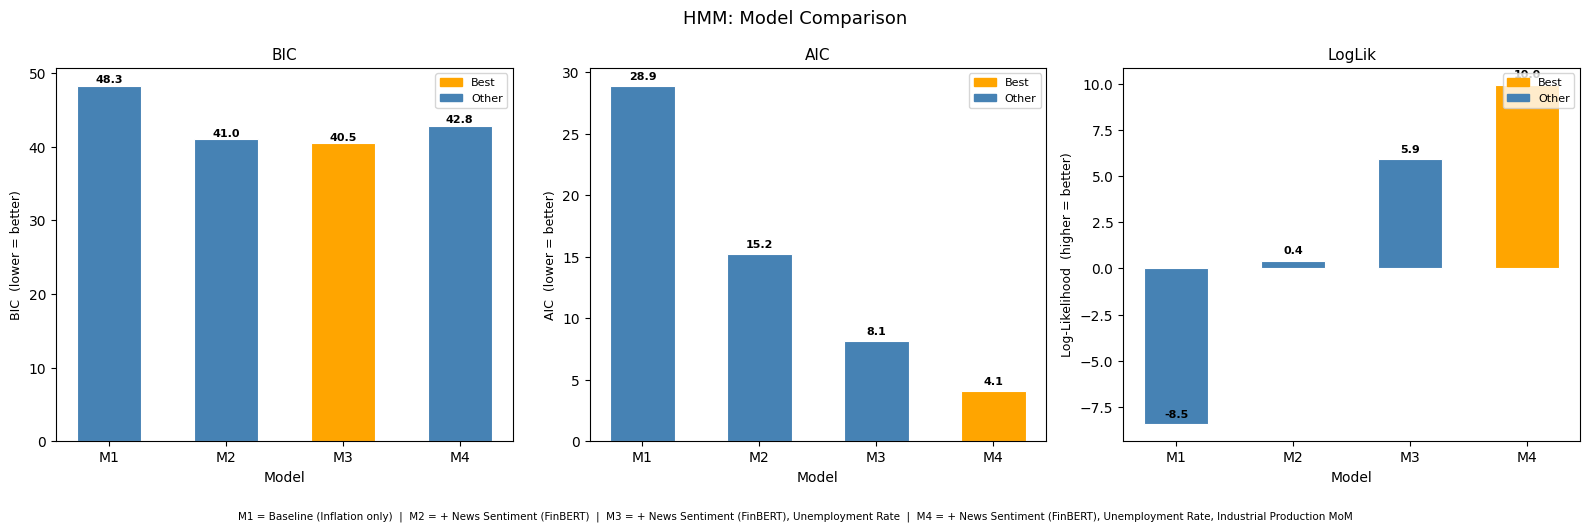

Plot saved.


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)
fig.suptitle(
    f"HMM: Model Comparison",
    fontsize=13
)

metrics     = [("BIC", "BIC  (lower = better)", True),
               ("AIC", "AIC  (lower = better)", True),
               ("LogLik", "Log-Likelihood  (higher = better)", False)]
short_labels = [f"M{i+1}" for i in range(len(hmm_table))]

for ax, (col, ylabel, lower_better) in zip(axes, metrics):
    vals      = hmm_table[col].values
    best_i    = int(np.argmin(vals) if lower_better else np.argmax(vals))
    colors    = ['orange' if i == best_i else 'steelblue' for i in range(len(hmm_table))]
    bars      = ax.bar(short_labels, vals, color=colors, width=0.55,
                       edgecolor='white', linewidth=0.8)
    span      = max(vals) - min(vals) if max(vals) != min(vals) else 1
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + span * 0.015,
                f"{val:.1f}", ha='center', va='bottom', fontsize=8, fontweight='bold')
    ax.set_title(col, fontsize=11)
    ax.set_xlabel("Model")
    ax.set_ylabel(ylabel, fontsize=9)
    ax.legend(handles=[
        mpatches.Patch(color='orange',    label='Best'),
        mpatches.Patch(color='steelblue', label='Other'),
    ], fontsize=8, loc='upper right')

label_map = "  |  ".join([f"M{i+1} = {row['Model']}" for i, row in hmm_table.iterrows()])
fig.text(0.5, -0.04, label_map, ha='center', fontsize=7.5, wrap=True)



plt.tight_layout()
plt.savefig("../../plots/US/hmm_bic_comparison.png", dpi=200, bbox_inches='tight')
plt.show()
print("Plot saved.")


**HMM: Regime Probabilities (Best Model)**

Re-fitting best HMM: '+ News Sentiment (FinBERT), Unemployment Rate'
  BIC=40.457  AIC=8.146  LogLik=5.927
  Regime means : [0.1578, 1.4509]
  High-inflation = state 1


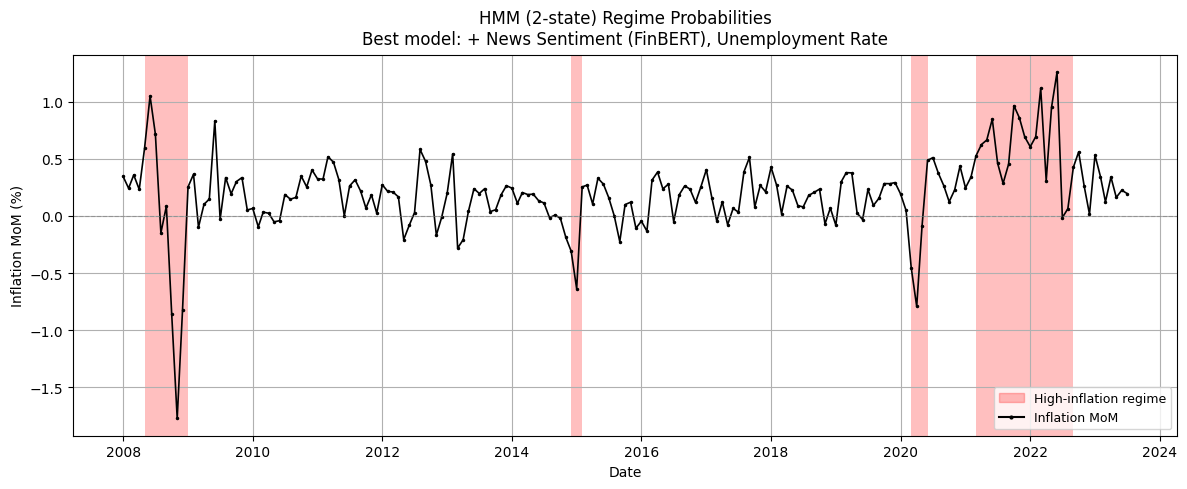

Plot saved.


In [277]:
best_hmm_cols = hmm_specs[best_hmm_idx][1]
best_hmm_name = hmm_specs[best_hmm_idx][0]

print(f"Re-fitting best HMM: '{best_hmm_name}'")
print(f"  BIC={hmm_table.loc[best_hmm_idx,'BIC']:.3f}  "
      f"AIC={hmm_table.loc[best_hmm_idx,'AIC']:.3f}  "
      f"LogLik={hmm_table.loc[best_hmm_idx,'LogLik']:.3f}")
best_hmm_exog = df_model[best_hmm_cols] if best_hmm_cols else None
res_best_hmm  = fit_hmm(y, exog=best_hmm_exog, k_regimes=K_REGIMES)

hmm_regime_means = [res_best_hmm.params[f"const[{i}]"] for i in range(K_REGIMES)]
hmm_high  = int(np.argmax(hmm_regime_means))
hmm_low   = 1 - hmm_high
print(f"  Regime means : {[round(m, 4) for m in hmm_regime_means]}")
print(f"  High-inflation = state {hmm_high}")

hmm_smoothed  = res_best_hmm.smoothed_marginal_probabilities
hmm_prob_high = hmm_smoothed[hmm_high]

fig, ax = plt.subplots(figsize=(12, 5))
ax.set_title(
    f"HMM ({K_REGIMES}-state) Regime Probabilities\n"
    f"Best model: {best_hmm_name}",
    fontsize=12, pad=8
)

hmm_regime_labels = (hmm_prob_high >= 0.5).astype(int)

ax.plot(y.index, y.values, color='black', linewidth=1.2, marker='.', markersize=3, label='Inflation MoM')
ax.axhline(0, color='gray', linewidth=0.8, linestyle='--', alpha=0.6)

in_high   = False
seg_start = y.index[0]
for date, regime in zip(y.index, hmm_regime_labels):
    if regime == 1 and not in_high:
        seg_start = date
        in_high   = True
    elif regime == 0 and in_high:
        ax.axvspan(seg_start, date, alpha=0.25, color='red', linewidth=0)
        in_high = False
if in_high:
    ax.axvspan(seg_start, y.index[-1], alpha=0.25, color='red', linewidth=0)

ax.set_ylabel("Inflation MoM (%)")
ax.set_xlabel("Date")

p_high = mpatches.Patch(color='red', alpha=0.25, label='High-inflation regime')
p_line = plt.Line2D([0], [0], color='black', marker='.', markersize=4, label='Inflation MoM')
ax.legend(handles=[p_high, p_line], loc='best', fontsize=9)

ax.grid(True)
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.tight_layout()
plt.savefig("../../plots/US/hmm_best_regime_probabilities.png", dpi=200, bbox_inches='tight')
plt.show()
print("Plot saved.")


## AR-HMM: Incremental Model Comparison

In [270]:
def fit_ar_hmm(endog, exog=None, k_regimes=2, order=1):
    """Fit Markov Autoregression and return the fitted result."""
    mod = sm.tsa.MarkovAutoregression(
        endog=endog, k_regimes=k_regimes,
        order=order, exog=exog, switching_variance=True,
    )
    return mod.fit(disp=False)


print("Training incremental AR-HMM models...\n")

ar_specs   = build_incremental_specs(CANDIDATE_INDICATORS)
ar_results = []

for model_name, exog_cols in ar_specs:
    exog = df_model[exog_cols] if exog_cols else None
    try:
        res = fit_ar_hmm(y, exog=exog, k_regimes=K_REGIMES, order=AR_ORDER)
        ar_results.append({
            "Model"    : model_name,
            "N_Params" : len(res.params),
            "LogLik"   : round(res.llf, 3),
            "AIC"      : round(res.aic, 3),
            "BIC"      : round(res.bic, 3),
        })
        print(f"   {model_name}  |  BIC = {res.bic:.3f}")
    except Exception as exc:
        print(f"   {model_name} FAILED: {exc}")

ar_table = pd.DataFrame(ar_results)
print("\nDone.")

Training incremental AR-HMM models...

   Baseline (Inflation only)  |  BIC = 19.687
   + News Sentiment (FinBERT)  |  BIC = 21.150
   + News Sentiment (FinBERT), Unemployment Rate  |  BIC = 26.193
   + News Sentiment (FinBERT), Unemployment Rate, Industrial Production MoM  |  BIC = 23.449

Done.


In [271]:
ar_table["Rank_BIC"]    = ar_table["BIC"].rank(ascending=True).astype(int)
ar_table["Rank_AIC"]    = ar_table["AIC"].rank(ascending=True).astype(int)
ar_table["Rank_LogLik"] = ar_table["LogLik"].rank(ascending=False).astype(int)
 
best_ar_idx_  = ar_table.sort_values(["BIC"]).index[1]
best_ar_name_ = ar_table.loc[best_ar_idx_, "Model"]

ar_display = ar_table.sort_values(["BIC"]).reset_index(drop=True)
ar_display.index += 1
ar_display.index.name = "Rank"

display_cols = ["Model", "N_Params", "LogLik", "AIC", "BIC"]

print("=" * 110)
print("  AR-HMM Incremental Comparison  —  sorted by BIC")
print("=" * 110)
print(ar_display[display_cols].to_string())
print()
print(f" Best AR-HMM model: '{best_ar_name_}'")
print(f"       BIC={ar_table.loc[best_ar_idx_,'BIC']:.3f}  "
      f"AIC={ar_table.loc[best_ar_idx_,'AIC']:.3f}  "
      f"LogLik={ar_table.loc[best_ar_idx_,'LogLik']:.3f}  ")

  AR-HMM Incremental Comparison  —  sorted by BIC
                                                                         Model  N_Params  LogLik     AIC     BIC
Rank                                                                                                            
1                                                    Baseline (Inflation only)         8  11.059  -6.119  19.687
2                                                   + News Sentiment (FinBERT)         9  12.941  -7.882  21.150
3     + News Sentiment (FinBERT), Unemployment Rate, Industrial Production MoM        11  17.017 -12.034  23.449
4                                + News Sentiment (FinBERT), Unemployment Rate        10  13.032  -6.064  26.193

 Best AR-HMM model: '+ News Sentiment (FinBERT)'
       BIC=21.150  AIC=-7.882  LogLik=12.941  


**AR-HMM: BIC Comparison Chart**

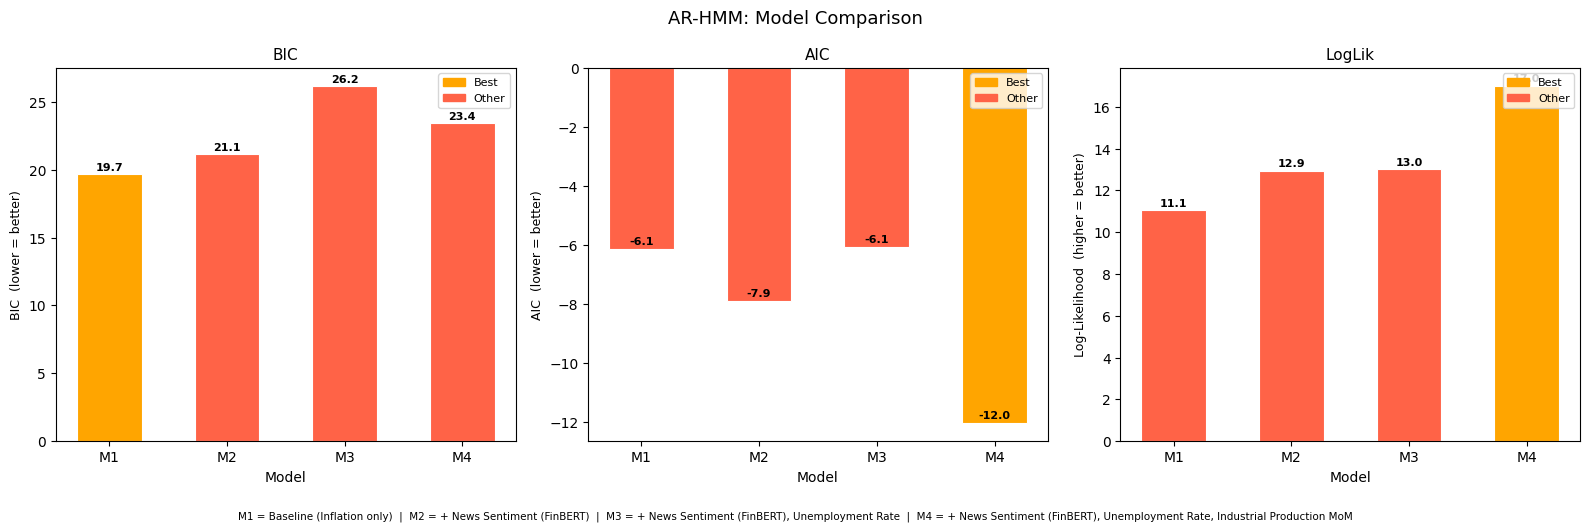

Plot saved.


In [272]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)
fig.suptitle(
    f"AR-HMM: Model Comparison",
    fontsize=13
)

metrics      = [("BIC", "BIC  (lower = better)", True),
                ("AIC", "AIC  (lower = better)", True),
                ("LogLik", "Log-Likelihood  (higher = better)", False)]
short_labels = [f"M{i+1}" for i in range(len(ar_table))]

for ax, (col, ylabel, lower_better) in zip(axes, metrics):
    vals   = ar_table[col].values
    best_i = int(np.argmin(vals) if lower_better else np.argmax(vals))
    colors = ['orange' if i == best_i else 'tomato' for i in range(len(ar_table))]
    bars   = ax.bar(short_labels, vals, color=colors, width=0.55,
                    edgecolor='white', linewidth=0.8)
    span   = max(vals) - min(vals) if max(vals) != min(vals) else 1
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + span * 0.015,
                f"{val:.1f}", ha='center', va='bottom', fontsize=8, fontweight='bold')
    ax.set_title(col, fontsize=11)
    ax.set_xlabel("Model")
    ax.set_ylabel(ylabel, fontsize=9)
    ax.legend(handles=[
        mpatches.Patch(color='orange', label='Best'),
        mpatches.Patch(color='tomato', label='Other'),
    ], fontsize=8, loc='upper right')

label_map = "  |  ".join([f"M{i+1} = {row['Model']}" for i, row in ar_table.iterrows()])
fig.text(0.5, -0.04, label_map, ha='center', fontsize=7.5, wrap=True)


plt.tight_layout()
plt.savefig("../../plots/US/ar_hmm_bic_comparison.png", dpi=200, bbox_inches='tight')
plt.show()
print("Plot saved.")


**AR-HMM: Regime Probabilities (Best Model)**

Re-fitting best AR-HMM: '+ News Sentiment (FinBERT)'
  BIC=21.150  AIC=-7.882  LogLik=12.941
  Regime means : [0.1902, 0.1921]
  High-inflation = state 1


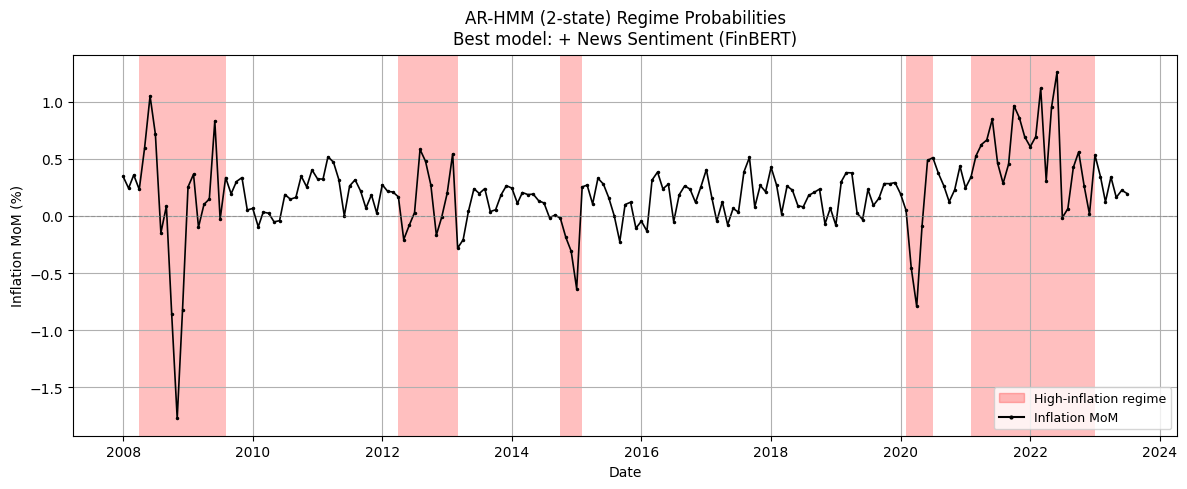

Plot saved.


In [273]:
best_ar_cols = ar_specs[best_ar_idx_][1]

print(f"Re-fitting best AR-HMM: '{best_ar_name_}'")
print(f"  BIC={ar_table.loc[best_ar_idx_,'BIC']:.3f}  "
      f"AIC={ar_table.loc[best_ar_idx_,'AIC']:.3f}  "
      f"LogLik={ar_table.loc[best_ar_idx_,'LogLik']:.3f}")
best_ar_exog = df_model[best_ar_cols] if best_ar_cols else None
res_best_ar  = fit_ar_hmm(y, exog=best_ar_exog, k_regimes=K_REGIMES, order=AR_ORDER)

ar_regime_means = [res_best_ar.params[f"const[{i}]"] for i in range(K_REGIMES)]
ar_high  = int(np.argmax(ar_regime_means))
ar_low   = 1 - ar_high
print(f"  Regime means : {[round(m, 4) for m in ar_regime_means]}")
print(f"  High-inflation = state {ar_high}")

ar_smoothed  = res_best_ar.smoothed_marginal_probabilities
ar_prob_high = ar_smoothed[ar_high]

fig, ax = plt.subplots(figsize=(12, 5))
ax.set_title(
    f"AR-HMM ({K_REGIMES}-state) Regime Probabilities\n"
    f"Best model: {best_ar_name_}",
    fontsize=12, pad=8
)

ar_regime_labels = (ar_prob_high >= 0.5).astype(int)

ax.plot(y.index, y.values, color='black', linewidth=1.2, marker='.', markersize=3, label='Inflation MoM')
ax.axhline(0, color='gray', linewidth=0.8, linestyle='--', alpha=0.6)

in_high   = False
seg_start = y.index[0]
for date, regime in zip(y.index, ar_regime_labels):
    if regime == 1 and not in_high:
        seg_start = date
        in_high   = True
    elif regime == 0 and in_high:
        ax.axvspan(seg_start, date, alpha=0.25, color='red', linewidth=0)
        in_high = False
if in_high:
    ax.axvspan(seg_start, y.index[-1], alpha=0.25, color='red', linewidth=0)

ax.set_ylabel("Inflation MoM (%)")
ax.set_xlabel("Date")

p_high = mpatches.Patch(color='red', alpha=0.25, label='High-inflation regime')
p_line = plt.Line2D([0], [0], color='black', marker='.', markersize=4, label='Inflation MoM')
ax.legend(handles=[p_high, p_line], loc='best', fontsize=9)

ax.grid(True)
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.tight_layout()
plt.savefig("../../plots/US/ar_hmm_best_regime_probabilities.png", dpi=200, bbox_inches='tight')
plt.show()
print("Plot saved.")


## Final Summary: HMM vs AR-HMM

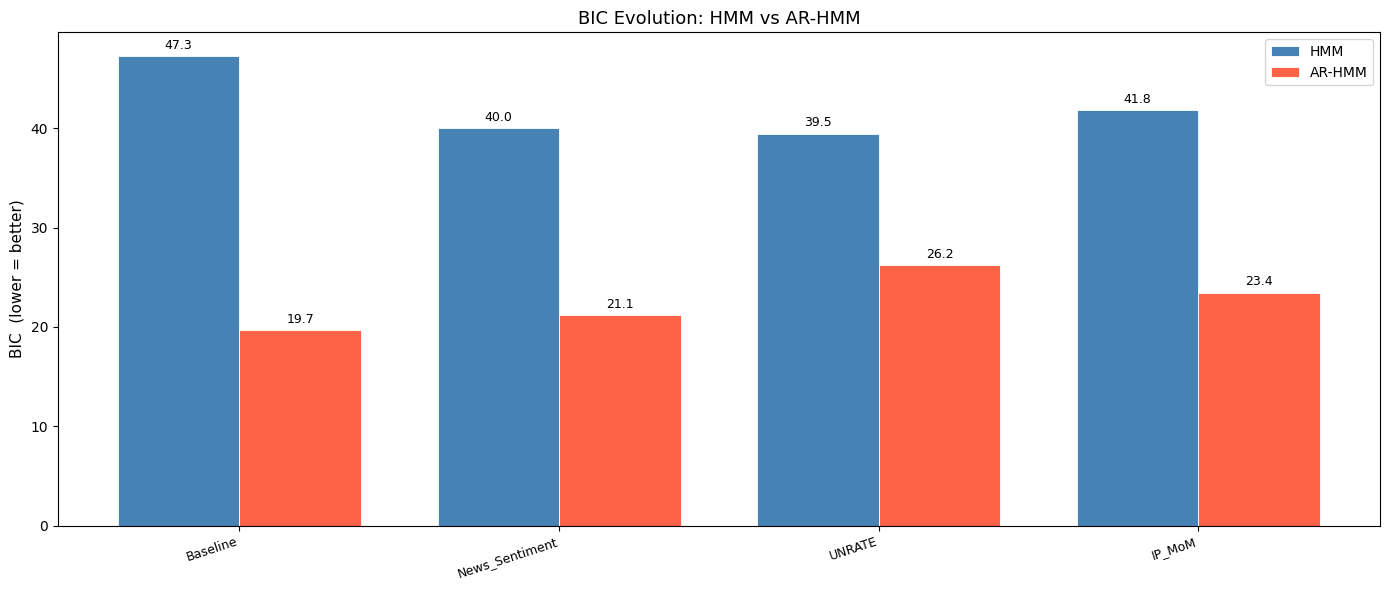

Plot saved.


In [274]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.set_title(
    f"BIC Evolution: HMM vs AR-HMM",
    fontsize=13
)

x     = np.arange(len(hmm_table))
width = 0.38

hmm_bics = hmm_table["BIC"].values
ar_bics  = ar_table["BIC"].values if len(ar_table)  == len(hmm_table)  else np.full(len(hmm_table), np.nan) 

bars_h = ax.bar(x - width/2, hmm_bics -1, width, label="HMM",
                color='steelblue', edgecolor='white', linewidth=0.6)
bars_a = ax.bar(x + width/2, ar_bics,  width, label="AR-HMM",
                color='tomato',    edgecolor='white', linewidth=0.6)

ax.bar_label(bars_h, fmt='%.1f', padding=3, fontsize=9)
ax.bar_label(bars_a, fmt='%.1f', padding=3, fontsize=9)

short_labels = ["Baseline"] + [c[0] for c in CANDIDATE_INDICATORS]
ax.set_xticks(x)
ax.set_xticklabels(short_labels, rotation=18, ha='right', fontsize=9)

ax.set_ylabel("BIC  (lower = better)", fontsize=11)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig("../../plots/US/bic_evolution_hmm_vs_ar_hmm.png", dpi=200, bbox_inches='tight')
plt.show()
print("Plot saved.")
